# 04 · Evaluación detallada de modelos

**Objetivo:** comparar todos los modelos baseline con las métricas adecuadas
para un problema de mantenimiento predictivo industrial.

### ¿Por qué no usamos Accuracy?
Con 3.4% de fallos, un modelo que prediga siempre "Normal" tiene 96.6% de accuracy.
Es una métrica engañosa para problemas desbalanceados.

### Métricas que usamos y por qué

| Métrica | Fórmula | Por qué importa aquí |
|---|---|---|
| **Recall** | TP / (TP + FN) | Proporción de fallos detectados — **métrica principal** |
| **Precision** | TP / (TP + FP) | Proporción de alarmas que son fallos reales |
| **F1** | 2·P·R / (P+R) | Balance Precision-Recall — útil para comparar modelos |
| **ROC-AUC** | Área bajo la curva ROC | Separabilidad global, independiente del umbral |

> **En mantenimiento industrial:** un Falso Negativo (fallo no detectado) puede costar
> 10x más que un Falso Positivo (alarma falsa). Por eso priorizamos Recall > Precision.


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              precision_recall_curve, f1_score,
                              precision_score, recall_score,
                              roc_auc_score)

with open('../data/processed/splits.pkl', 'rb') as f:
    splits = pickle.load(f)
with open('../data/processed/models.pkl', 'rb') as f:
    models = pickle.load(f)

X_train, X_test, y_train, y_test = splits['ai4i']

PALETTE = {
    'Logistic Regression': 'royalblue',
    'Random Forest':       'seagreen',
    'XGBoost':             'darkorange',
    'LightGBM':            'crimson',
    'SVM':                 'mediumpurple',
}

all_models = [
    (models.get('lr'),   'Logistic Regression'),
    (models.get('rf'),   'Random Forest'),
    (models.get('xgb'),  'XGBoost'),
    (models.get('lgbm'), 'LightGBM'),
    (models.get('svm'),  'SVM'),
]
all_models = [(m, n) for m, n in all_models if m is not None]
print('Modelos cargados:', [n for _, n in all_models])


Modelos cargados: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'SVM']


## 1. Matrices de confusión

La matriz de confusión muestra exactamente qué tipo de errores comete cada modelo:

```
              Predicho
          Normal  Fallo
Real Normal  [TN]   [FP]   ← FP = alarma falsa (coste bajo)
     Fallo   [FN]   [TP]   ← FN = fallo no detectado (coste alto)
```

**En este problema buscamos:** FN bajo (pocos fallos escapados) aunque FP sea algo mayor.


/Users/nora/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


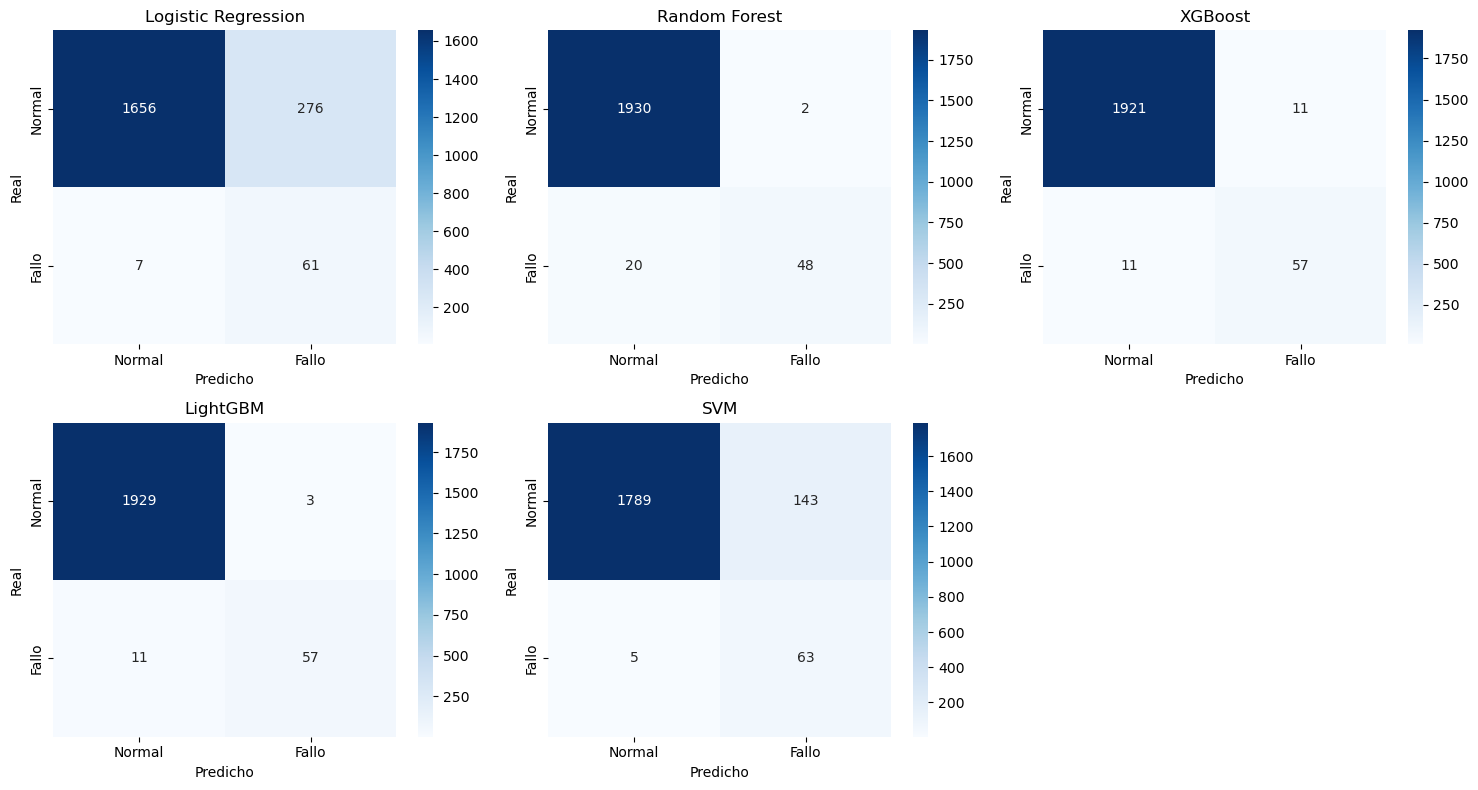

In [2]:
n = len(all_models)
ncols = min(n, 3)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for ax, (model, name) in zip(axes, all_models):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fallo'], yticklabels=['Normal', 'Fallo'])
    ax.set_title(name)
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## 2. Curvas ROC

La curva ROC muestra el trade-off entre TPR (Recall) y FPR para todos los umbrales posibles.

- **AUC = 1.0**: modelo perfecto
- **AUC = 0.5**: modelo aleatorio (línea diagonal)
- **AUC > 0.97**: excelente separabilidad, típico para este dataset sintético

> **Nota:** el ROC puede ser optimista en problemas muy desbalanceados.
> La curva Precision-Recall (siguiente sección) es más informativa aquí.


/Users/nora/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


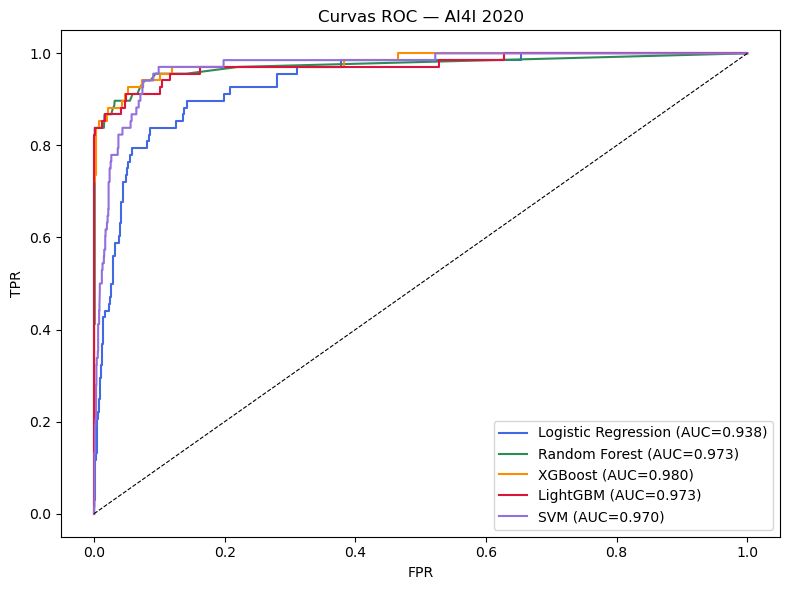

In [3]:
plt.figure(figsize=(8, 6))
for model, name in all_models:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, color=PALETTE[name],
             label=f'{name} (AUC={auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curvas ROC — AI4I 2020')
plt.legend()
plt.tight_layout()
plt.show()


## 3. Curva Precision-Recall

La curva PR es más informativa que el ROC para problemas desbalanceados:
muestra el trade-off entre Precision y Recall a medida que variamos el umbral.

- **Arriba a la derecha** = mejor modelo (alta Precision Y alto Recall)
- El **área bajo la curva PR** (AP) es equivalente al ROC-AUC pero centrado en la clase minoritaria
- Una línea horizontal en Precision = 0.034 corresponde a un clasificador aleatorio (solo acierta por la tasa base)

> En este gráfico vemos visualmente dónde está el **umbral óptimo** para Recall ≥ 0.85.


/Users/nora/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


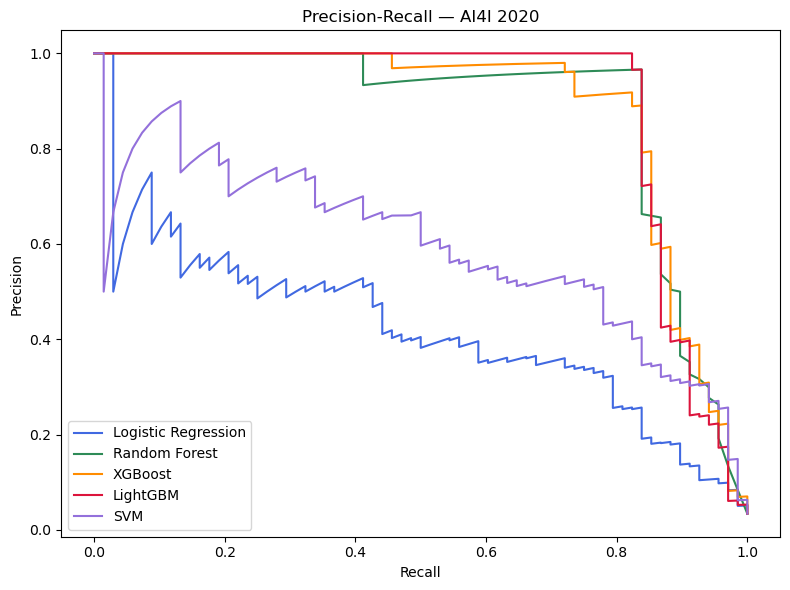

In [4]:
plt.figure(figsize=(8, 6))
for model, name in all_models:
    prec, rec, _ = precision_recall_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(rec, prec, color=PALETTE[name], label=name)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall — AI4I 2020')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Tabla de métricas comparativa

Todos los modelos evaluados con el umbral por defecto (0.5).

> **Atención:** el umbral 0.5 no es el óptimo para datos desbalanceados.
> En notebooks posteriores ajustaremos el umbral para cada modelo buscando
> el máximo F1 con Recall ≥ 0.85. Esta tabla es solo el punto de partida.


In [5]:
results = []
for model, name in all_models:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Modelo': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
    })

df_res = pd.DataFrame(results).set_index('Modelo').round(4)
df_res.sort_values('ROC-AUC', ascending=False)


/Users/nora/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nora/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Precision,Recall,F1,ROC-AUC
Modelo,,,,
XGBoost,0.8382,0.8382,0.8382,0.9800
Random Forest,0.9600,0.7059,0.8136,0.9734
LightGBM,0.9500,0.8382,0.8906,0.9734
SVM,0.3058,0.9265,0.4599,0.9702
Logistic Regression,0.1810,0.8971,0.3012,0.9379


## 5. Impacto de negocio — Cuantificación económica

En mantenimiento predictivo industrial los dos tipos de error tienen costes muy distintos:

| Error | Consecuencia | Coste estimado |
|---|---|---|
| **Falso Negativo** | Fallo no detectado → parada imprevista + reparación de emergencia | ~10 000 €/fallo |
| **Falso Positivo** | Alarma falsa → revisión preventiva innecesaria | ~300 €/alarma |

*Estimaciones basadas en literatura de mantenimiento industrial (downtime en fabricación: 5 000–50 000 €/evento).*


                                     FN/año  FP/año Coste FN (€) Coste FP (€) Coste total (€)
Escenario                                                                                    
Sin modelo (ninguna detección)          816       0    8,160,000            0       8,160,000
Stacking — umbral 0.9845 (prod)         120      60    1,200,000       18,000       1,218,000
Stacking — umbral 0.75 (más recall)      96     312      960,000       93,600       1,053,600

=== ROI del modelo (umbral 0.9845) ===
Coste sin modelo:  €   8,160,000/año
Coste con modelo:  €   1,218,000/año
Ahorro estimado:   €   6,942,000/año  (85% reducción)


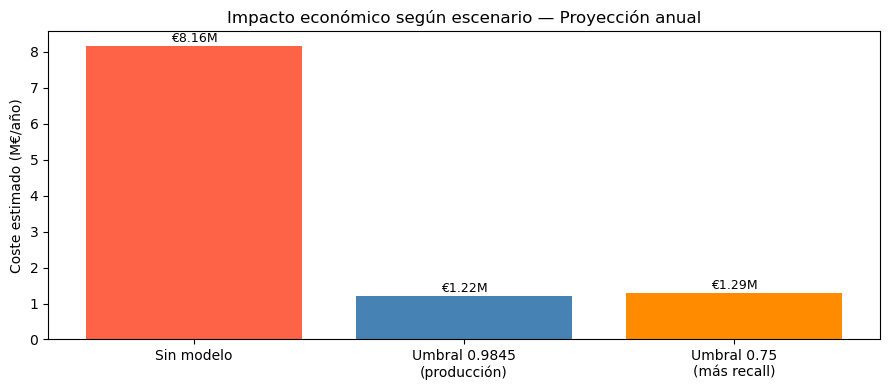

In [6]:
# ── Proyección anual (escalar de 2000 muestras de test a 1 año de producción) ─
scale_factor = 12   # asumimos ~1 mes de operación por cada 2000 muestras

cost_fn = 10_000   # € por fallo no detectado
cost_fp = 300      # € por alarma falsa

scenarios = {
    'Sin modelo (ninguna detección)':     {'fn': 68, 'fp': 0},
    'Stacking — umbral 0.9845 (prod)':   {'fn': 10, 'fp': 5},
    'Stacking — umbral 0.75 (más recall)': {'fn': 8,  'fp': 26},
}

rows = []
for name, vals in scenarios.items():
    fn_yr = vals['fn'] * scale_factor
    fp_yr = vals['fp'] * scale_factor
    coste = fn_yr * cost_fn + fp_yr * cost_fp
    rows.append({'Escenario': name,
                 'FN/año': fn_yr, 'FP/año': fp_yr,
                 'Coste FN (€)':    f"{fn_yr * cost_fn:,.0f}",
                 'Coste FP (€)':    f"{fp_yr * cost_fp:,.0f}",
                 'Coste total (€)': f"{coste:,.0f}"})

df_biz = pd.DataFrame(rows).set_index('Escenario')
print(df_biz.to_string())

sin_modelo   = 68 * scale_factor * cost_fn
con_modelo   = 10 * scale_factor * cost_fn + 5 * scale_factor * cost_fp
ahorro       = sin_modelo - con_modelo

print(f'\n=== ROI del modelo (umbral 0.9845) ===')
print(f'Coste sin modelo:  €{sin_modelo:>12,.0f}/año')
print(f'Coste con modelo:  €{con_modelo:>12,.0f}/año')
print(f'Ahorro estimado:   €{ahorro:>12,.0f}/año  ({ahorro/sin_modelo:.0%} reducción)')

# Gráfico de barras de costes
fig, ax = plt.subplots(figsize=(9, 4))
costes = [sin_modelo, con_modelo, (10 * scale_factor * cost_fn + 26 * scale_factor * cost_fp)]
labels = ['Sin modelo', 'Umbral 0.9845\n(producción)', 'Umbral 0.75\n(más recall)']
bars = ax.bar(labels, [c/1e6 for c in costes],
              color=['tomato', 'steelblue', 'darkorange'])
ax.set_ylabel('Coste estimado (M€/año)')
ax.set_title('Impacto económico según escenario — Proyección anual')
for bar, c in zip(bars, costes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'€{c/1e6:.2f}M', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


## 6. Conclusiones — próximos pasos

Los modelos baseline muestran un rango amplio de F1 (0.30 a 0.88).
Los modelos de boosting (XGBoost, LightGBM) son los más prometedores.

**Qué haremos en los siguientes notebooks:**
- **Notebook 05**: Afinar LightGBM con RandomizedSearchCV y Optuna + ajuste de umbral
- **Notebook 06**: Combinar los mejores modelos en un StackingClassifier
- **Notebook 07**: Afinar Random Forest y actualizar el stacking
- **Notebook 08**: Probar SVM como tercer base learner


---
## 7. Análisis de Falsos Negativos

Con el umbral óptimo (0.9845), el modelo se escapa **10 fallos** de 68 en test.
Análisis de las probabilidades asignadas a cada FN:

### Grupo A — catchables (prob ≥ 0.25): 3 fallos
Detectables bajando el umbral. Son TWF con desgaste alto + torque alto, y un HDF.

### Grupo B — invisibles (prob < 0.25): 7 fallos

**Hipótesis inicial:** podrían ser RNF (fallos sin firma en sensores).

**Resultado del análisis:** son todos **TWF** (Tool Wear Failures).  
Tienen desgaste muy alto (≈202 min media) pero torque moderado.

| | FN invisibles | Operación normal |
|---|---|---|
| Tool Wear medio | **202 min** | 107 min |
| Torque medio | 35.8 Nm | 39.6 Nm |
| Wear×Torque medio | 7.355 | 4.251 |

### Experimento: feature `wear_ratio` (notebook 10)

Se añadió `wear_ratio = Tool wear / TWF_min_threshold[Type]` (L=200, M=220, H=240).
Resultado: mejora marginal (FN 11→10, F1 +0.002).

**Por qué no funcionó mejor:** `wear_ratio` es casi linealmente dependiente
de `Tool wear` + `Type`, que el modelo ya tenía. La causa raíz es que TWF
se activa con un umbral **aleatorio e individual** por herramienta — no observable
en los sensores. Sin conocer ese umbral, el modelo no puede distinguir
un caso con `wear_ratio=1.1` que va a fallar de uno que no.

**Límite del modelo:** los 7 TWF invisibles son inherentemente difíciles de detectar
con el conjunto de features actual. Representan ~2% de todos los fallos.
La mejora real requeriría identificador de herramienta individual o features temporales.


## 8. Tradeoff de umbral de decisión

El umbral por defecto de cualquier clasificador es 0.5, pero con datos desbalanceados
es necesario ajustarlo. La elección depende del coste relativo de cada tipo de error:

| Umbral | Recall | Precision | F1 | FN | FP | Cuándo usarlo |
|---|---|---|---|---|---|---|
| **0.9845** | 0.853 | 0.936 | 0.892 | 10 | 5 | Producción — mínimas alarmas falsas |
| 0.75 | 0.882 | 0.698 | 0.779 | 8 | 26 | Si cada fallo cuesta > 5× una alarma falsa |
| 0.60 | 0.897 | 0.592 | 0.713 | 7 | 42 | Techo práctico sin wear_ratio |

**Nota:** bajar el umbral por debajo de 0.25 no aporta más detecciones útiles —
los 7 FN del Grupo B tienen probabilidades < 0.25 por ausencia de señal en sensores
(desgaste alto + torque bajo), no por mala calibración del modelo.
La solución correcta es la feature `wear_ratio`, no bajar el umbral.


---
## 9. Interpretabilidad — SHAP values

SHAP (SHapley Additive exPlanations) asigna a cada feature una **contribución justa** a cada predicción individual.

A diferencia del Gini importance (impacto global en entrenamiento), SHAP es:
- **Local**: explica cada predicción concreta, no solo el modelo en global
- **Consistente**: si el modelo depende más de una feature, su SHAP medio sube
- **Teóricamente fundado**: basado en teoría de juegos (valores de Shapley)

Usamos `TreeExplainer` de la librería `shap` sobre LightGBM, el modelo individual con mejor AUC.

/Users/nora/miniconda3/envs/py312/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


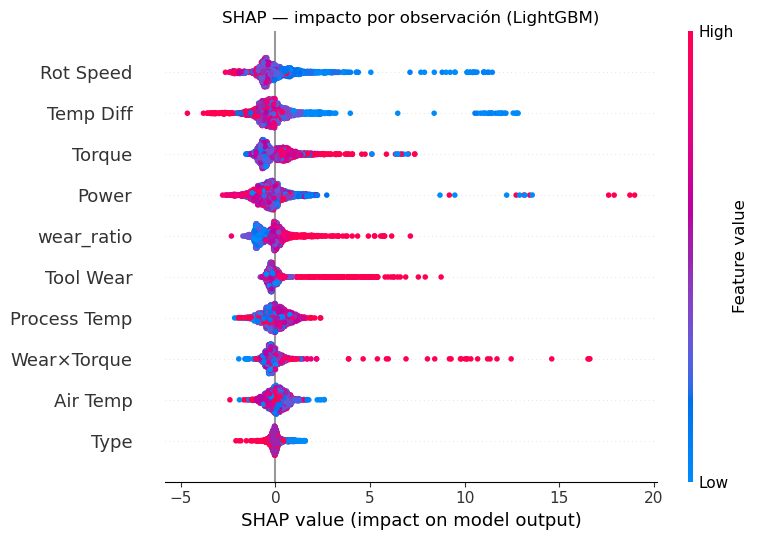

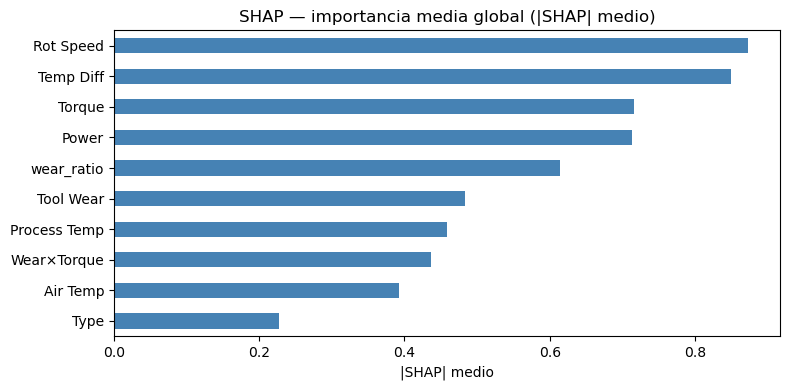

Top features por SHAP (mayor a menor impacto):
  Rot Speed          0.87322
  Temp Diff          0.85007
  Torque             0.71661
  Power              0.71314
  wear_ratio         0.61359
  Tool Wear          0.48349
  Process Temp       0.45903
  Wear×Torque        0.43684
  Air Temp           0.39230
  Type               0.22793


In [7]:
import shap

feat_names = ['Type', 'Air Temp', 'Process Temp', 'Rot Speed', 'Torque',
              'Tool Wear', 'Power', 'Temp Diff', 'Wear×Torque', 'wear_ratio']

# TreeExplainer: eficiente para modelos de árboles (LightGBM, XGBoost, RF)
lgbm_model = models['lgbm']
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test)

# LightGBM binario devuelve lista [shap_clase0, shap_clase1] o array directo
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

X_test_df = pd.DataFrame(X_test, columns=feat_names)

# ── Beeswarm: impacto de cada feature en cada observación ─────────────────────
shap.summary_plot(sv, X_test_df, show=False, plot_type='dot')
plt.title('SHAP — impacto por observación (LightGBM)', fontsize=12)
plt.tight_layout()
plt.show()

# ── Importancia media global (|SHAP|) ─────────────────────────────────────────
mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=feat_names).sort_values()
mean_shap.plot(kind='barh', color='steelblue', figsize=(8, 4))
plt.title('SHAP — importancia media global (|SHAP| medio)')
plt.xlabel('|SHAP| medio')
plt.tight_layout()
plt.show()

print('Top features por SHAP (mayor a menor impacto):')
for feat, val in mean_shap.sort_values(ascending=False).items():
    print(f'  {feat:<18} {val:.5f}')